## 1. Imports et Configuration


In [ ]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Imports OK!


## 2. Hyperparamètres AMÉLIORÉS


In [ ]:
# Chemins
DATA_DIR = IMAGES_DIR
OUTPUT_DIR = artifacts_for("multitask", "multitask_model_v2")
ARTIFACTS_DIR = OUTPUT_DIR

# Hyperparamètres AMÉLIORÉS
IMG_SIZE = 128
BATCH_SIZE = 32

# Plus d'epochs pour mieux converger
WARMUP_EPOCHS = 20  # Était 15
FINETUNE_EPOCHS = 60  # Était 40

# Learning rates ajustés
INITIAL_LR = 5e-4  # Un peu plus bas pour stabilité
FINETUNE_LR = 2e-5  # Était 1e-5

# Splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# Classes
ETHNICITY_CLASSES = ["White", "Black", "Asian", "Indian", "Others"]
GENDER_CLASSES = ["Male", "Female"]
NUM_ETHNICITY_CLASSES = len(ETHNICITY_CLASSES)

print("Dataset:", DATA_DIR)
print("Output:", OUTPUT_DIR)
print("Configuration V2 (Améliorée):")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Warmup epochs: {WARMUP_EPOCHS}")
print(f"  - Finetune epochs: {FINETUNE_EPOCHS}")
print(f"  - Initial LR: {INITIAL_LR}")
print(f"  - Finetune LR: {FINETUNE_LR}")

Configuration V2 (Améliorée):
  - Image size: 128x128
  - Batch size: 32
  - Warmup epochs: 20
  - Finetune epochs: 60
  - Initial LR: 0.0005
  - Finetune LR: 2e-05


## 3. Chargement des Données


In [3]:
def parse_utkface_filename(filepath):
    """Parse le nom de fichier UTKFace."""
    filename = Path(filepath).stem
    parts = filename.split("_")

    if len(parts) >= 3:
        try:
            age = int(parts[0])
            gender = int(parts[1])
            ethnicity = int(parts[2])

            if 0 <= age <= 116 and gender in [0, 1] and 0 <= ethnicity <= 4:
                return {
                    "filepath": str(filepath),
                    "age": age,
                    "gender": gender,
                    "ethnicity": ethnicity,
                }
        except (ValueError, IndexError):
            pass
    return None


# Charger
image_paths = list(DATA_DIR.glob("*.jpg")) + list(DATA_DIR.glob("*.JPG"))
print(f"Images trouvées: {len(image_paths)}")

records = [parse_utkface_filename(path) for path in tqdm(image_paths, desc="Parsing")]
records = [r for r in records if r is not None]

df = pd.DataFrame(records)
print(f"Images valides: {len(df)}")

# Nettoyage outliers
z_scores = np.abs(stats.zscore(df["age"]))
df_clean = df[z_scores <= 3].copy()
print(f"Après nettoyage: {len(df_clean)}")

# Distribution
print(f"\nDistribution ethnicité:")
print(df_clean["ethnicity"].value_counts().sort_index())

Images trouvées: 23708


Parsing: 100%|██████████| 23708/23708 [00:00<00:00, 350702.58it/s]

Images valides: 23705
Après nettoyage: 23633

Distribution ethnicité:
ethnicity
0    10034
1     4520
2     3415
3     3972
4     1692
Name: count, dtype: int64


## 4. Split et Poids de Classes


In [4]:
# Données
X = df_clean["filepath"].values
y_age = df_clean["age"].values.astype(np.float32)
y_gender = df_clean["gender"].values.astype(np.int32)
y_ethnicity = df_clean["ethnicity"].values.astype(np.int32)

# Split
(
    X_trainval,
    X_test,
    y_age_trainval,
    y_age_test,
    y_gender_trainval,
    y_gender_test,
    y_eth_trainval,
    y_eth_test,
) = train_test_split(
    X,
    y_age,
    y_gender,
    y_ethnicity,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=y_ethnicity,
)

val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
(
    X_train,
    X_val,
    y_age_train,
    y_age_val,
    y_gender_train,
    y_gender_val,
    y_eth_train,
    y_eth_val,
) = train_test_split(
    X_trainval,
    y_age_trainval,
    y_gender_trainval,
    y_eth_trainval,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_eth_trainval,
)

print(f"Split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# Poids de classes pour l'ethnicité (IMPORTANT pour le déséquilibre)
ethnicity_weights = compute_class_weight(
    "balanced", classes=np.unique(y_eth_train), y=y_eth_train
)
ethnicity_class_weights = dict(enumerate(ethnicity_weights))
print(f"\nPoids ethnicité: {ethnicity_class_weights}")

# Convertir en tensor pour Focal Loss
class_weights_tensor = tf.constant(
    [ethnicity_class_weights[i] for i in range(NUM_ETHNICITY_CLASSES)], dtype=tf.float32
)

Split: Train=16543, Val=3545, Test=3545

Poids ethnicité: {0: np.float64(0.4710421412300683), 1: np.float64(1.045701643489254), 2: np.float64(1.3837724801338351), 3: np.float64(1.1901438848920862), 4: np.float64(2.794425675675676)}


I0000 00:00:1768746265.635356  124628 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1205 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## 5. Focal Loss (Meilleur pour classes déséquilibrées)


In [5]:
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss pour classification multi-classe.
    Réduit l'importance des exemples faciles, focus sur les difficiles.
    """

    def __init__(
        self, gamma=2.0, alpha=None, class_weights=None, name="focal_loss", **kwargs
    ):
        # Accept and pass any extra arguments (like 'reduction') to parent class
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha  # Pour le déséquilibre binaire
        self.class_weights = class_weights  # Pour multi-classe

    def call(self, y_true, y_pred):
        # Clip pour éviter log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # One-hot encode si nécessaire
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(tf.squeeze(y_true), depth=tf.shape(y_pred)[-1])

        # Cross entropy
        ce = -y_true_one_hot * tf.math.log(y_pred)

        # Focal weight
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1 - p_t, self.gamma)

        # Apply class weights if provided
        if self.class_weights is not None:
            weights = tf.reduce_sum(
                y_true_one_hot * self.class_weights, axis=-1, keepdims=True
            )
            focal_weight = focal_weight * weights

        focal_loss = focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "alpha": self.alpha,
                "class_weights": (
                    self.class_weights.numpy().tolist()
                    if self.class_weights is not None
                    else None
                ),
            }
        )
        return config

    @classmethod
    def from_config(cls, config):
        # Rebuild class_weights as tensor if present
        class_weights = config.pop("class_weights", None)
        if class_weights is not None:
            class_weights = tf.constant(class_weights, dtype=tf.float32)
        return cls(class_weights=class_weights, **config)


print("Focal Loss définie - gamma=2.0 (focus sur exemples difficiles)")

Focal Loss définie - gamma=2.0 (focus sur exemples difficiles)


## 6. Data Augmentation Renforcée


In [6]:
# Augmentation plus agressive
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),  # Était 0.1
        layers.RandomZoom(0.2),  # Était 0.15
        layers.RandomTranslation(0.15, 0.15),  # Était 0.1
        layers.RandomBrightness(0.3),  # Était 0.2
        layers.RandomContrast(0.3),  # Était 0.2
    ],
    name="data_augmentation",
)

print("Data augmentation renforcée:")
for layer in data_augmentation.layers:
    print(f"  - {layer.name}")

Data augmentation renforcée:
  - random_flip
  - random_rotation
  - random_zoom
  - random_translation
  - random_brightness
  - random_contrast


## 7. Pipeline de Données avec Sample Weights


In [7]:
def load_and_preprocess(filepath, age, gender, ethnicity):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, {
        "age_output": age,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def create_dataset(filepaths, ages, genders, ethnicities, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, ages, genders, ethnicities))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=2000)  # Buffer plus grand

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train, y_age_train, y_gender_train, y_eth_train, training=True
)
val_ds = create_dataset(X_val, y_age_val, y_gender_val, y_eth_val, training=False)
test_ds = create_dataset(X_test, y_age_test, y_gender_test, y_eth_test, training=False)

print(f"Datasets créés")

Datasets créés


## 8. Architecture AMÉLIORÉE avec Attention


In [8]:
class SqueezeExcitation(layers.Layer):
    """Squeeze-and-Excitation block pour channel attention."""

    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.squeeze = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // self.ratio, activation="relu")
        self.fc2 = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))

    def call(self, inputs):
        x = self.squeeze(inputs)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.reshape(x)
        return inputs * x


def build_multitask_model_v2(input_shape=(IMG_SIZE, IMG_SIZE, 3), training=True):
    """Modèle multi-tâche V2 avec améliorations."""

    inputs = layers.Input(shape=input_shape, name="input_image")

    # Data augmentation
    x = data_augmentation(inputs) if training else inputs

    # Backbone
    backbone = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    backbone.trainable = False

    features = backbone.output

    # Squeeze-Excitation attention
    features = SqueezeExcitation(ratio=16, name="se_attention")(features)

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(features)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(features)
    pooled = layers.Concatenate(name="concat_pooling")([gap, gmp])

    # Couches partagées PLUS PROFONDES
    shared = layers.Dense(1024, kernel_regularizer=l2(1e-4), name="shared_dense1")(
        pooled
    )
    shared = layers.BatchNormalization(name="shared_bn1")(shared)
    shared = layers.Activation("relu")(shared)
    shared = layers.Dropout(0.5, name="shared_dropout1")(shared)

    shared = layers.Dense(512, kernel_regularizer=l2(1e-4), name="shared_dense2")(
        shared
    )
    shared = layers.BatchNormalization(name="shared_bn2")(shared)
    shared = layers.Activation("relu")(shared)
    shared = layers.Dropout(0.4, name="shared_dropout2")(shared)

    # === HEAD ÂGE (Plus profond) ===
    age_branch = layers.Dense(256, kernel_regularizer=l2(1e-4), name="age_dense1")(
        shared
    )
    age_branch = layers.BatchNormalization(name="age_bn1")(age_branch)
    age_branch = layers.Activation("relu")(age_branch)
    age_branch = layers.Dropout(0.3, name="age_dropout1")(age_branch)

    age_branch = layers.Dense(128, kernel_regularizer=l2(1e-4), name="age_dense2")(
        age_branch
    )
    age_branch = layers.BatchNormalization(name="age_bn2")(age_branch)
    age_branch = layers.Activation("relu")(age_branch)
    age_branch = layers.Dropout(0.2, name="age_dropout2")(age_branch)

    age_output = layers.Dense(1, activation="linear", name="age_output")(age_branch)

    # === HEAD GENRE (Plus profond) ===
    gender_branch = layers.Dense(
        256, kernel_regularizer=l2(1e-4), name="gender_dense1"
    )(shared)
    gender_branch = layers.BatchNormalization(name="gender_bn1")(gender_branch)
    gender_branch = layers.Activation("relu")(gender_branch)
    gender_branch = layers.Dropout(0.3, name="gender_dropout1")(gender_branch)

    gender_branch = layers.Dense(
        128, kernel_regularizer=l2(1e-4), name="gender_dense2"
    )(gender_branch)
    gender_branch = layers.BatchNormalization(name="gender_bn2")(gender_branch)
    gender_branch = layers.Activation("relu")(gender_branch)
    gender_branch = layers.Dropout(0.2, name="gender_dropout2")(gender_branch)

    gender_output = layers.Dense(1, activation="sigmoid", name="gender_output")(
        gender_branch
    )

    # === HEAD ETHNICITÉ (Plus profond) ===
    eth_branch = layers.Dense(256, kernel_regularizer=l2(1e-4), name="eth_dense1")(
        shared
    )
    eth_branch = layers.BatchNormalization(name="eth_bn1")(eth_branch)
    eth_branch = layers.Activation("relu")(eth_branch)
    eth_branch = layers.Dropout(0.3, name="eth_dropout1")(eth_branch)

    eth_branch = layers.Dense(128, kernel_regularizer=l2(1e-4), name="eth_dense2")(
        eth_branch
    )
    eth_branch = layers.BatchNormalization(name="eth_bn2")(eth_branch)
    eth_branch = layers.Activation("relu")(eth_branch)
    eth_branch = layers.Dropout(0.2, name="eth_dropout2")(eth_branch)

    ethnicity_output = layers.Dense(
        NUM_ETHNICITY_CLASSES, activation="softmax", name="ethnicity_output"
    )(eth_branch)

    model = Model(
        inputs=inputs,
        outputs=[age_output, gender_output, ethnicity_output],
        name="multitask_face_model_v2",
    )

    return model, backbone


model, backbone = build_multitask_model_v2(training=True)
model.summary()

Model: "multitask_face_model_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati

 Total params: 7,907,322 (30.16 MB)

 Trainable params: 3,852,375 (14.70 MB)

 Non-trainable params: 4,054,947 (15.47 MB)

## 9. Compilation avec Losses Améliorées


In [9]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.01,  # Decay plus agressif
)

# Losses AMÉLIORÉES
losses = {
    "age_output": keras.losses.Huber(
        delta=3.0
    ),  # Delta plus petit pour être plus sensible
    "gender_output": keras.losses.BinaryCrossentropy(
        label_smoothing=0.1
    ),  # Label smoothing
    "ethnicity_output": FocalLoss(
        gamma=2.0, class_weights=class_weights_tensor
    ),  # Focal Loss!
}

# Poids des losses AJUSTÉS
# L'âge et l'ethnicité sont plus difficiles, leur donner plus de poids
loss_weights = {
    "age_output": 2.0,  # Augmenté
    "gender_output": 1.0,
    "ethnicity_output": 2.0,  # Augmenté
}

metrics = {
    "age_output": ["mae", "mse"],
    "gender_output": ["accuracy", keras.metrics.AUC(name="auc")],
    "ethnicity_output": ["accuracy"],
}

# AdamW au lieu de Adam (meilleure régularisation)
model.compile(
    optimizer=AdamW(learning_rate=warmup_lr_schedule, weight_decay=1e-5),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

print("Modèle V2 compilé avec:")
print(f"  - Loss âge: Huber (δ=3.0)")
print(f"  - Loss genre: BinaryCrossentropy + Label Smoothing 0.1")
print(f"  - Loss ethnicité: Focal Loss (γ=2.0) + Class Weights")
print(f"  - Optimizer: AdamW avec weight decay")
print(f"  - Loss weights: {loss_weights}")

Modèle V2 compilé avec:
  - Loss âge: Huber (δ=3.0)
  - Loss genre: BinaryCrossentropy + Label Smoothing 0.1
  - Loss ethnicité: Focal Loss (γ=2.0) + Class Weights
  - Optimizer: AdamW avec weight decay
  - Loss weights: {'age_output': 2.0, 'gender_output': 1.0, 'ethnicity_output': 2.0}


## 10. Callbacks


In [10]:
warmup_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "multitask_v2_warmup_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,  # Plus de patience
        restore_best_weights=True,
        verbose=1,
    ),
]

print("Callbacks warmup configurés")

Callbacks warmup configurés


## 11. Phase 1: Warmup


In [11]:
print("=" * 60)
print("PHASE 1: WARMUP (Backbone gelé)")
print("=" * 60)

trainable_count = np.sum(
    [keras.backend.count_params(w) for w in model.trainable_weights]
)
print(f"Paramètres entraînables: {trainable_count:,}")

warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

PHASE 1: WARMUP (Backbone gelé)
Paramètres entraînables: 3,852,375
Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - age_output_loss: 79.7759 - age_output_mae: 28.0481 - age_output_mse: 1137.6156 - ethnicity_output_accuracy: 0.2650 - ethnicity_output_loss: 1.2396 - gender_output_accuracy: 0.6279 - gender_output_auc: 0.6745 - gender_output_loss: 0.6794 - loss: 163.0892
Epoch 1: val_loss improved from None to 69.67510, saving model to artifacts/multitask_v2_warmup_best.keras

Epoch 1: finished saving model to artifacts/multitask_v2_warmup_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - age_output_loss: 65.6803 - age_output_mae: 23.3280 - age_output_mse: 868.6597 - ethnicity_output_accuracy: 0.2896 - ethnicity_output_loss: 1.1403 - gender_output_accuracy: 0.6755 - gender_output_auc: 0.7368 - gender_output_loss: 0.6358 - loss: 134.6712 - val_age_output_loss: 33.4282 - val_age_output_mae: 12.5029 - val_age_output_mse: 303.8332 - val_ethnicity_output_accuracy: 0.4054 - val_ethni

## 12. Phase 2: Fine-tuning (Dégel plus agressif)


In [12]:
print("=" * 60)
print("PHASE 2: FINE-TUNING (Dégel 70 dernières couches)")
print("=" * 60)

# Dégeler PLUS de couches (70 au lieu de 50)
backbone.trainable = True
freeze_until = len(backbone.layers) - 70  # Plus agressif

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = np.sum(
    [keras.backend.count_params(w) for w in model.trainable_weights]
)
print(f"Paramètres entraînables après dégel: {trainable_count:,}")

# Nouveau LR schedule
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS
finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR,
    decay_steps=total_finetune_steps,
    alpha=0.001,  # Decay très bas
)

model.compile(
    optimizer=AdamW(learning_rate=finetune_lr_schedule, weight_decay=1e-5),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

finetune_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "multitask_v2_model_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,  # Plus de patience
        restore_best_weights=True,
        verbose=1,
    ),
]

finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

PHASE 2: FINE-TUNING (Dégel 70 dernières couches)
Paramètres entraînables après dégel: 6,914,707
Epoch 1/60


E0000 00:00:1768746703.226370  124628 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/multitask_face_model_v2_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


516/517 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - age_output_loss: 31.1308 - age_output_mae: 11.7578 - age_output_mse: 261.4311 - ethnicity_output_accuracy: 0.4124 - ethnicity_output_loss: 0.9234 - gender_output_accuracy: 0.6746 - gender_output_auc: 0.8091 - gender_output_loss: 0.6313 - loss: 65.2640
Epoch 1: val_loss improved from None to 49.36552, saving model to artifacts/multitask_v2_model_best.keras

Epoch 1: finished saving model to artifacts/multitask_v2_model_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - age_output_loss: 28.6935 - age_output_mae: 10.9367 - age_output_mse: 228.8002 - ethnicity_output_accuracy: 0.4149 - ethnicity_output_loss: 0.9016 - gender_output_accuracy: 0.6810 - gender_output_auc: 0.7796 - gender_output_loss: 0.6209 - loss: 60.3366 - val_age_output_loss: 23.3595 - val_age_output_mae: 9.1059 - val_age_output_mse: 163.0393 - val_ethnicity_output_accuracy: 0.4897 - val_ethnicity_output_loss: 0.7894 - val_gender_output_accuracy: 0.7622 - val_gender_output_au

## 13. Visualisation de l'Entraînement


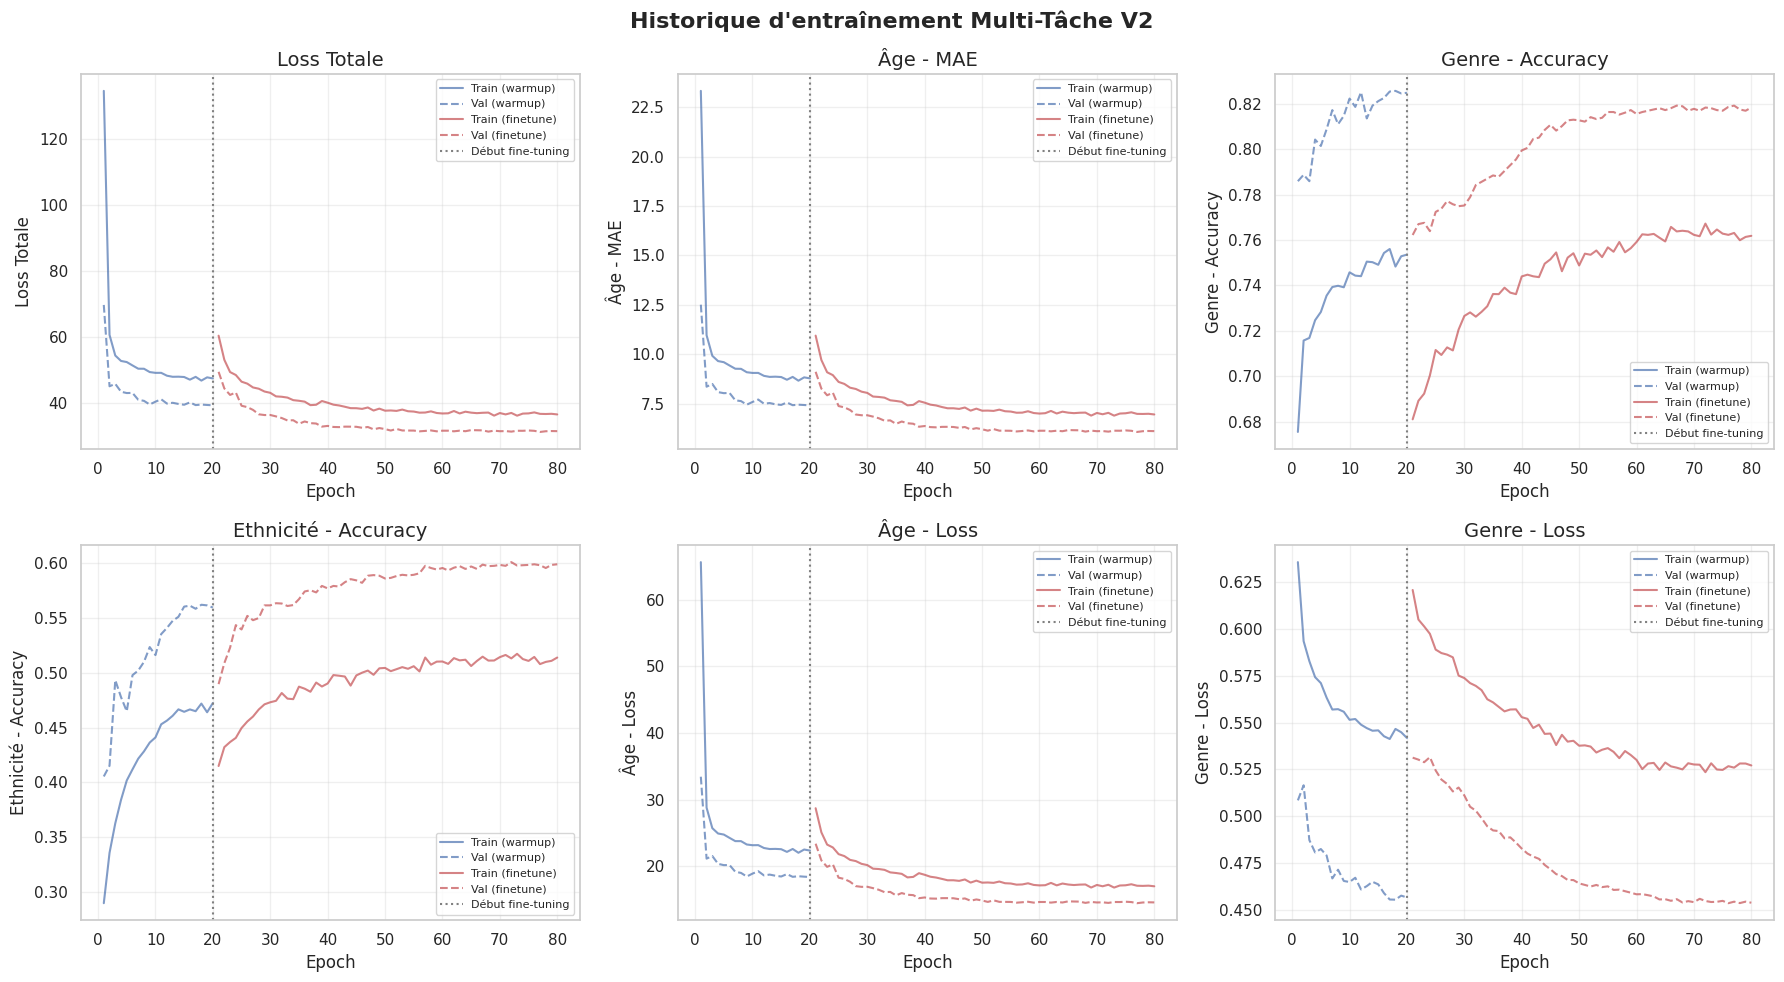

In [13]:
def plot_multitask_history(warmup_history, finetune_history):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    warmup_epochs = len(warmup_history.history["loss"])

    metrics_to_plot = [
        ("loss", "Loss Totale"),
        ("age_output_mae", "Âge - MAE"),
        ("gender_output_accuracy", "Genre - Accuracy"),
        ("ethnicity_output_accuracy", "Ethnicité - Accuracy"),
        ("age_output_loss", "Âge - Loss"),
        ("gender_output_loss", "Genre - Loss"),
    ]

    for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
        if metric in warmup_history.history:
            train_warmup = warmup_history.history[metric]
            val_warmup = warmup_history.history.get(f"val_{metric}", [])

            epochs_warmup = range(1, len(train_warmup) + 1)
            ax.plot(
                epochs_warmup, train_warmup, "b-", label="Train (warmup)", alpha=0.7
            )
            if val_warmup:
                ax.plot(
                    epochs_warmup, val_warmup, "b--", label="Val (warmup)", alpha=0.7
                )

        if metric in finetune_history.history:
            train_ft = finetune_history.history[metric]
            val_ft = finetune_history.history.get(f"val_{metric}", [])

            epochs_ft = range(warmup_epochs + 1, warmup_epochs + len(train_ft) + 1)
            ax.plot(epochs_ft, train_ft, "r-", label="Train (finetune)", alpha=0.7)
            if val_ft:
                ax.plot(epochs_ft, val_ft, "r--", label="Val (finetune)", alpha=0.7)

        ax.axvline(
            x=warmup_epochs, color="gray", linestyle=":", label="Début fine-tuning"
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Historique d'entraînement Multi-Tâche V2", fontsize=16, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(
        ARTIFACTS_DIR / "multitask_v2_training_history.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


plot_multitask_history(warmup_history, finetune_history)

## 14. Évaluation


In [14]:
# Charger le meilleur modèle
best_model = keras.models.load_model(
    ARTIFACTS_DIR / "multitask_v2_model_best.keras",
    custom_objects={"FocalLoss": FocalLoss, "SqueezeExcitation": SqueezeExcitation},
)

# Prédictions
predictions = best_model.predict(test_ds, verbose=1)
y_pred_age = predictions[0].flatten()
y_pred_gender = (predictions[1].flatten() > 0.5).astype(int)
y_pred_ethnicity = np.argmax(predictions[2], axis=1)

# Métriques
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    mean_absolute_error,
)

mae_age = mean_absolute_error(y_age_test, y_pred_age)
rmse_age = np.sqrt(np.mean((y_age_test - y_pred_age) ** 2))
acc_gender = accuracy_score(y_gender_test, y_pred_gender)
f1_gender = f1_score(y_gender_test, y_pred_gender)
acc_ethnicity = accuracy_score(y_eth_test, y_pred_ethnicity)
f1_ethnicity_macro = f1_score(y_eth_test, y_pred_ethnicity, average="macro")
f1_ethnicity_weighted = f1_score(y_eth_test, y_pred_ethnicity, average="weighted")

print("\n" + "=" * 60)
print("RÉSULTATS MODÈLE MULTI-TÂCHE V2")
print("=" * 60)
print(f"\n🎂 ÂGE:")
print(f"   MAE: {mae_age:.2f} années")
print(f"   RMSE: {rmse_age:.2f} années")
print(f"\n👫 GENRE:")
print(f"   Accuracy: {acc_gender*100:.2f}%")
print(f"   F1-Score: {f1_gender:.4f}")
print(f"\n🌍 ETHNICITÉ:")
print(f"   Accuracy: {acc_ethnicity*100:.2f}%")
print(f"   F1-Score (macro): {f1_ethnicity_macro:.4f}")
print(f"   F1-Score (weighted): {f1_ethnicity_weighted:.4f}")

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step

RÉSULTATS MODÈLE MULTI-TÂCHE V2

🎂 ÂGE:
   MAE: 5.78 années
   RMSE: 8.41 années

👫 GENRE:
   Accuracy: 81.95%
   F1-Score: 0.8009

🌍 ETHNICITÉ:
   Accuracy: 59.80%
   F1-Score (macro): 0.5109
   F1-Score (weighted): 0.6008


## 15. Rapports de Classification


In [15]:
print("\n" + "=" * 60)
print("RAPPORT - GENRE")
print("=" * 60)
print(classification_report(y_gender_test, y_pred_gender, target_names=GENDER_CLASSES))

print("\n" + "=" * 60)
print("RAPPORT - ETHNICITÉ")
print("=" * 60)
print(
    classification_report(y_eth_test, y_pred_ethnicity, target_names=ETHNICITY_CLASSES)
)


RAPPORT - GENRE
              precision    recall  f1-score   support

        Male       0.80      0.87      0.83      1851
      Female       0.85      0.76      0.80      1694

    accuracy                           0.82      3545
   macro avg       0.82      0.82      0.82      3545
weighted avg       0.82      0.82      0.82      3545


RAPPORT - ETHNICITÉ
              precision    recall  f1-score   support

       White       0.74      0.72      0.73      1505
       Black       0.72      0.73      0.72       678
       Asian       0.51      0.61      0.56       512
      Indian       0.47      0.27      0.34       596
      Others       0.16      0.28      0.21       254

    accuracy                           0.60      3545
   macro avg       0.52      0.52      0.51      3545
weighted avg       0.62      0.60      0.60      3545



## 16. Matrices de Confusion


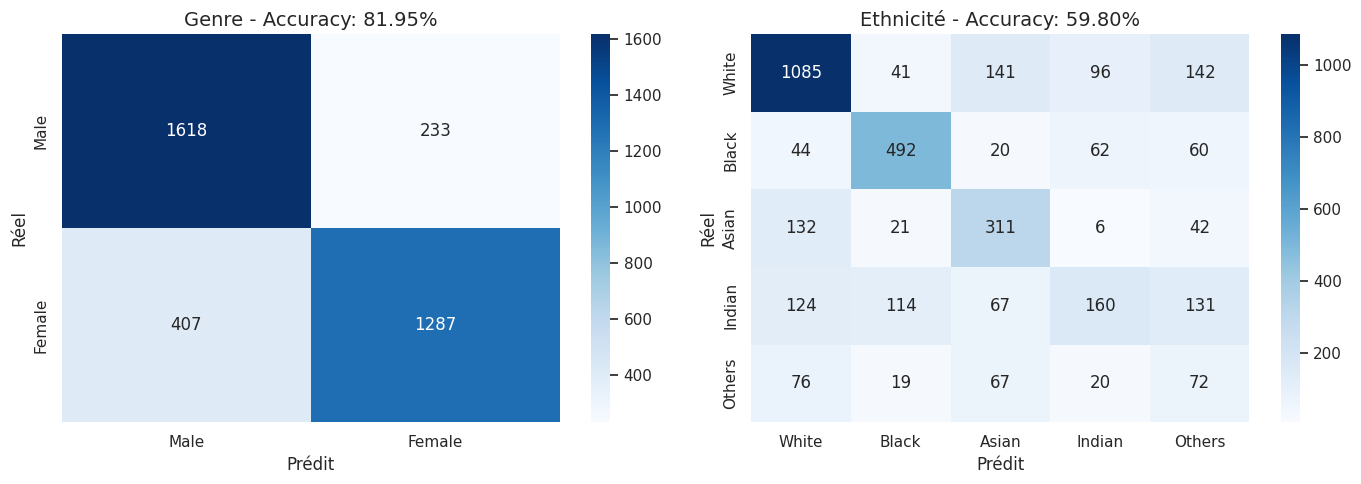

In [16]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre
cm_gender = confusion_matrix(y_gender_test, y_pred_gender)
sns.heatmap(
    cm_gender,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=GENDER_CLASSES,
    yticklabels=GENDER_CLASSES,
    ax=axes[0],
)
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title(f"Genre - Accuracy: {acc_gender*100:.2f}%")

# Ethnicité
cm_ethnicity = confusion_matrix(y_eth_test, y_pred_ethnicity)
sns.heatmap(
    cm_ethnicity,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ETHNICITY_CLASSES,
    yticklabels=ETHNICITY_CLASSES,
    ax=axes[1],
)
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title(f"Ethnicité - Accuracy: {acc_ethnicity*100:.2f}%")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "multitask_v2_confusion_matrices.png", dpi=150)
plt.show()

## 17. Exemples de Prédictions


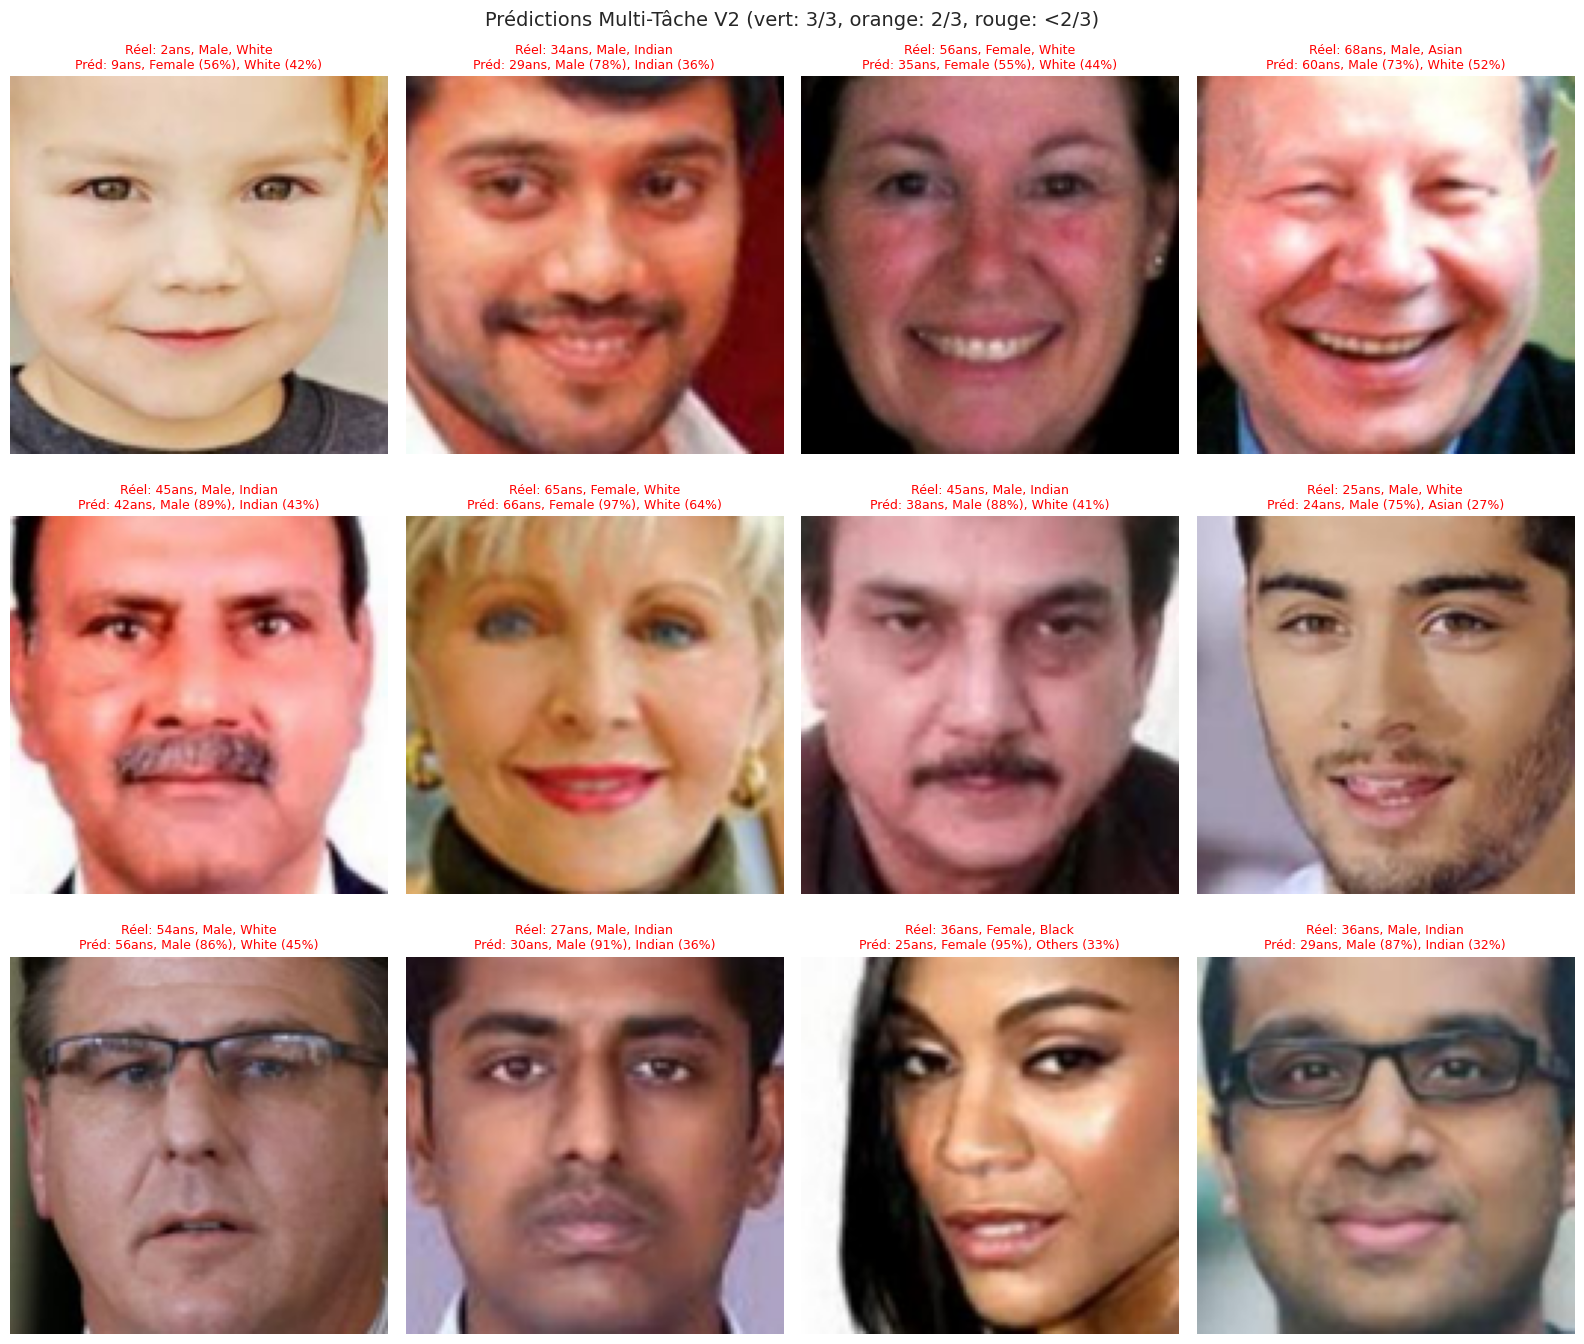

In [17]:
def show_predictions_v2(
    model, filepaths, true_ages, true_genders, true_ethnicities, n_samples=12
):
    indices = np.random.choice(len(filepaths), n_samples, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(16, 14))

    for idx, ax in zip(indices, axes.flat):
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)

        preds = model.predict(img_array[np.newaxis, ...], verbose=0)
        pred_age = preds[0][0, 0]
        pred_gender = "Female" if preds[1][0, 0] > 0.5 else "Male"
        pred_gender_conf = max(preds[1][0, 0], 1 - preds[1][0, 0])
        pred_eth_idx = np.argmax(preds[2][0])
        pred_eth = ETHNICITY_CLASSES[pred_eth_idx]
        pred_eth_conf = preds[2][0, pred_eth_idx]

        true_age = true_ages[idx]
        true_gender = GENDER_CLASSES[true_genders[idx]]
        true_eth = ETHNICITY_CLASSES[true_ethnicities[idx]]

        age_error = abs(pred_age - true_age)
        gender_correct = pred_gender == true_gender
        eth_correct = pred_eth == true_eth

        n_correct = (age_error < 5) + gender_correct + eth_correct
        color = "green" if n_correct == 3 else ("orange" if n_correct >= 2 else "red")

        ax.imshow(img_array.astype(np.uint8))
        ax.set_title(
            f"Réel: {true_age:.0f}ans, {true_gender}, {true_eth}\n"
            f"Préd: {pred_age:.0f}ans, {pred_gender} ({pred_gender_conf*100:.0f}%), {pred_eth} ({pred_eth_conf*100:.0f}%)",
            fontsize=9,
            color=color,
        )
        ax.axis("off")

    plt.suptitle(
        "Prédictions Multi-Tâche V2 (vert: 3/3, orange: 2/3, rouge: <2/3)", fontsize=14
    )
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "multitask_v2_predictions_examples.png", dpi=150)
    plt.show()


show_predictions_v2(best_model, X_test, y_age_test, y_gender_test, y_eth_test)

## 18. Sauvegarde et Conversion TFLite


In [ ]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "multitask_v2_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "multitask_v2_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

tflite_size_mb = tflite_path.stat().st_size / (1024 * 1024)
print(f"TFLite sauvegardé: {tflite_path} ({tflite_size_mb:.2f} MB)")

Modèle sauvegardé: artifacts/multitask_v2_model_final.keras
INFO:tensorflow:Assets written to: /tmp/tmpg6kaw8cz/assets


INFO:tensorflow:Assets written to: /tmp/tmpg6kaw8cz/assets


Saved artifact at '/tmp/tmpg6kaw8cz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)]
Captures:
  135265659405136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135265659414928: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135263691808336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263691807376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263691806608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263691809104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263691809680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263691809872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135263691806992

W0000 00:00:1768748297.604201  124628 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768748297.604228  124628 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1768748297.739864  124628 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


TFLite sauvegardé: artifacts/multitask_v2_model.tflite (15.05 MB)


## 19. Métadonnées


In [19]:
import json

model_info = {
    "model_type": "multitask_v2",
    "version": "2.0",
    "img_size": IMG_SIZE,
    "input_range": [0, 255],
    "improvements": [
        "Deeper heads (256->128)",
        "Focal Loss for ethnicity",
        "Label smoothing for gender",
        "Squeeze-Excitation attention",
        "AdamW optimizer",
        "More aggressive backbone unfreezing",
    ],
    "outputs": {
        "age": {"type": "regression", "output_name": "age_output"},
        "gender": {
            "type": "binary_classification",
            "output_name": "gender_output",
            "classes": GENDER_CLASSES,
            "threshold": 0.5,
        },
        "ethnicity": {
            "type": "multiclass_classification",
            "output_name": "ethnicity_output",
            "classes": ETHNICITY_CLASSES,
        },
    },
    "metrics": {
        "age_mae": float(mae_age),
        "age_rmse": float(rmse_age),
        "gender_accuracy": float(acc_gender),
        "gender_f1": float(f1_gender),
        "ethnicity_accuracy": float(acc_ethnicity),
        "ethnicity_f1_macro": float(f1_ethnicity_macro),
        "ethnicity_f1_weighted": float(f1_ethnicity_weighted),
    },
}

info_path = ARTIFACTS_DIR / "multitask_v2_model_info.json"
with open(info_path, "w") as f:
    json.dump(model_info, f, indent=2)

print(f"Métadonnées sauvegardées: {info_path}")
print(json.dumps(model_info, indent=2))

Métadonnées sauvegardées: artifacts/multitask_v2_model_info.json
{
  "model_type": "multitask_v2",
  "version": "2.0",
  "img_size": 128,
  "input_range": [
    0,
    255
  ],
  "improvements": [
    "Deeper heads (256->128)",
    "Focal Loss for ethnicity",
    "Label smoothing for gender",
    "Squeeze-Excitation attention",
    "AdamW optimizer",
    "More aggressive backbone unfreezing"
  ],
  "outputs": {
    "age": {
      "type": "regression",
      "output_name": "age_output"
    },
    "gender": {
      "type": "binary_classification",
      "output_name": "gender_output",
      "classes": [
        "Male",
        "Female"
      ],
      "threshold": 0.5
    },
    "ethnicity": {
      "type": "multiclass_classification",
      "output_name": "ethnicity_output",
      "classes": [
        "White",
        "Black",
        "Asian",
        "Indian",
        "Others"
      ]
    }
  },
  "metrics": {
    "age_mae": 5.781609058380127,
    "age_rmse": 8.411046028137207,
    "gen

## 20. Résumé Final


In [20]:
print("=" * 60)
print("RÉSUMÉ MODÈLE MULTI-TÂCHE V2")
print("=" * 60)
print(f"\n📊 Architecture:")
print(f"   - Backbone: EfficientNetB0 + SE Attention")
print(f"   - Couches partagées: 1024 → 512")
print(f"   - Heads: 256 → 128 (plus profonds)")
print(f"\n⚡ Améliorations:")
print(f"   - Focal Loss pour ethnicité")
print(f"   - Label Smoothing pour genre")
print(f"   - AdamW optimizer")
print(f"   - 70 couches dégelées")
print(f"\n📈 Performances:")
print(f"   🎂 Âge: MAE={mae_age:.2f}, RMSE={rmse_age:.2f}")
print(f"   👫 Genre: Acc={acc_gender*100:.2f}%, F1={f1_gender:.4f}")
print(f"   🌍 Ethnicité: Acc={acc_ethnicity*100:.2f}%, F1={f1_ethnicity_macro:.4f}")
print(f"\n💾 Fichiers:")
print(f"   - {final_model_path}")
print(f"   - {tflite_path} ({tflite_size_mb:.2f} MB)")
print("=" * 60)

RÉSUMÉ MODÈLE MULTI-TÂCHE V2

📊 Architecture:
   - Backbone: EfficientNetB0 + SE Attention
   - Couches partagées: 1024 → 512
   - Heads: 256 → 128 (plus profonds)

⚡ Améliorations:
   - Focal Loss pour ethnicité
   - Label Smoothing pour genre
   - AdamW optimizer
   - 70 couches dégelées

📈 Performances:
   🎂 Âge: MAE=5.78, RMSE=8.41
   👫 Genre: Acc=81.95%, F1=0.8009
   🌍 Ethnicité: Acc=59.80%, F1=0.5109

💾 Fichiers:
   - artifacts/multitask_v2_model_final.keras
   - artifacts/multitask_v2_model.tflite (15.05 MB)
